This script is used to both calculate and plot regressions.

In [2]:
# import functions
# OS interaction and time
import os
import sys
import cftime
import datetime
import time
import glob
import dask
import dask.bag as db
from dask.diagnostics import ProgressBar
from dask.distributed import Client
import calendar
import importlib

# math and data
import math
import numpy as np
import netCDF4 as nc
import xarray as xr
from functools import partial
import scipy as sp
import scipy.linalg
from scipy.signal import detrend
import pandas as pd
import pickle as pickle
from sklearn import linear_model
import matplotlib.patches as mpatches
from shapely.geometry.polygon import LinearRing
import statsmodels.stats.multitest as multitest

# plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import ticker
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import matplotlib.image as mpimg
from matplotlib.colors import TwoSlopeNorm
import matplotlib.cm as cm

from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.axes_divider import HBoxDivider
import mpl_toolkits.axes_grid1.axes_size as Size
from mpl_toolkits.axes_grid1 import make_axes_locatable

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

# random
from IPython.display import display
from IPython.display import HTML
import IPython.core.display as di # Example: di.display_html('<h3>%s:</h3>' % str, raw=True)

# paths to various directories
rda_era5_path = '/glade/campaign/collections/rda/data/ds633.0/'  # base path to ERA5 data on derecho
my_era5_path = '/glade/u/home/zcleveland/scratch/ERA5/'  # path to subset data
misc_data_path = '/glade/u/home/zcleveland/scratch/misc_data/'  # path to misc data
plot_out_path = '/glade/u/home/zcleveland/NAM_soil-moisture/ERA5_analysis/plots/'  # path to generated plots
fig_out_path = '/glade/u/home/zcleveland/NAM_soil-moisture/ERA5_analysis/figures/'  # path to generated figures
scripts_main_path = '/glade/u/home/zcleveland/NAM_soil-moisture/scripts_main/'  # path to my dicts, lists, and functions

# import variable lists and dictionaries
if scripts_main_path not in sys.path:
    sys.path.insert(0, scripts_main_path)  # path to file containing these lists/dicts
if 'get_var_data' in sys.modules:
    importlib.reload(sys.modules['get_var_data'])
if 'my_functions' in sys.modules:
    importlib.reload(sys.modules['my_functions'])
if 'my_dictionaries' in sys.modules:
    importlib.reload(sys.modules['my_dictionaries'])

# import common functions that I've created
from get_var_data import get_var_data, get_var_files, open_var_data, subset_var_data, time_to_year_month_avg, time_to_year_month_sum, time_to_year_month
from my_functions import month_num_to_name, ensure_var_list

# import lists and dictionaries
from my_dictionaries import (
sfc_instan_list, sfc_accumu_list, pl_var_list, derived_var_list, invar_var_list,
NAM_var_list, region_avg_list, flux_var_list, vector_var_list, misc_var_list,
var_dict, var_units, region_avg_dict, region_avg_coords, region_colors_dict
)

In [3]:
# define the function to calculate the regression between two variables
def main_regression(var1, var1_region, var1_months, var2, var2_region, var2_months, **kwargs):
    # get kwargs
    save_png = kwargs.get('save_png', False)
    show_png = kwargs.get('show_png', False)
    overwrite_flag = kwargs.get('overwrite_flag', False)

    # make sure that if var1 or var2 are a list, they are contained in the vector_var_list
    if isinstance(var1, list) and var1 not in vector_var_list:
        raise ValueError(f"List of var1 must be an option of vector_var_list: {vector_var_list}\nvar1: {var1}")
    if isinstance(var2, list) and var2 not in vector_var_list:
        raise ValueError(f"List of var2 must be an option of vector_var_list: {vector_var_list}\nvar1: {var2}")

    # get month names for each var
    var1_month_names = month_num_to_name(ensure_var_list(var1)[0], var1_months)
    var2_month_names = month_num_to_name(ensure_var_list(var2)[0], var2_months)

    # get core and output filenames and output file paths
    fn_core, out_fn = get_out_fn(var1, var1_region, var1_month_names, var2, var2_region, var2_month_names, **kwargs)
    out_fp = get_out_fp(out_fn, var1_region, var2_region, **kwargs)

    # check if the .nc file already exists for the regression
    if os.path.exists(out_fp):
        if not overwrite_flag:  # only overwrite if specified by user
            print(f'{out_fn} already exists...')
            if show_png:
                print('Showing saved plot...')
                # fig_title = make_fig_title(var1, var1_region, var1_month_names, var2, var2_region, var2_month_names, **kwargs)
                # show_regression(out_fp, fig_title, **kwargs)
            return
        else:
            print('overwrite_flag is True. Overwriting . . .')
    # process data
    if isinstance(var1, list):
        u_var_data, v_var_data = process_vector_data(var1, var1_region, var1_months, kwargs.get('var1_level', None), kwargs.get('var1_elevation_mask', None))
        var1_data = None
        var2_data = process_non_vector_data(var2, var2_region, var2_months, kwargs.get('var2_level', None), kwargs.get('var2_elevation_mask', None))
    elif isinstance(var2, list):
        u_var_data, v_var_data = process_vector_data(var2, var2_region, var2_months, kwargs.get('var2_level', None), kwargs.get('var2_elevation_mask', None))
        var1_data = process_non_vector_data(var1, var1_region, var1_months, kwargs.get('var1_level', None), kwargs.get('var1_elevation_mask', None))
        var2_data = None
    else:
        var1_data = process_non_vector_data(var1, var1_region, var1_months, kwargs.get('var1_level', None), kwargs.get('var1_elevation_mask', None))
        var2_data = process_non_vector_data(var2, var2_region, var2_months, kwargs.get('var2_level', None), kwargs.get('var2_elevation_mask', None))
        u_var_data = None
        v_var_data = None

    # process regression
    regression_ds, u_regression_ds, v_regression_ds = process_regression(var1_data, u_var_data, v_var_data, var2_data)

    # plot regression
    fig, ax = plot_regression(regression_ds, u_regression_ds, v_regression_ds)

    if kwargs.get('plot_type', 'plot') == 'plot':  # add colorbar, contours, and title
        fig_title = make_fig_title(var1, var1_region, var1_month_names, var2, var2_region, var2_month_names, **kwargs)
        plt.title(fig_title)

    with ProgressBar():
        if kwargs.get('save_png', False):
            plt.savefig(out_fp, dpi=kwargs.get('dpi', 300), bbox_inches='tight')
        if kwargs.get('show_png', True):
            plt.show()
    plt.close()

In [4]:
def plot_regression(regression_ds, u_regression_ds, v_regression_ds):
    if regression_ds is not None:
        rvalue = regression_ds['rvalue']
        pvalue = regression_ds['pvalue']
        vmin, vmax = -1, 1
    else:
        rvalue = np.sqrt(u_regression_ds['rvalue']**2 + v_regression_ds['rvalue']**2)
        pvalue = np.sqrt(u_regression_ds['pvalue']**2 + v_regression_ds['pvalue']**2)
        vmin, vmax = 0, 1

    # set up figure parameters
    cf_levels = np.arange(vmin, vmax + 0.01, 0.01)
    norm = plt.Normalize(vmin, vmax)
    cmap = 'Reds' if vmin == 0 else 'RdBu_r'

    projection = ccrs.PlateCarree()
    fig, ax = plt.subplots(figsize=(12,10), subplot_kw=dict(projection=ccrs.PlateCarree()))

    # shaded contours of rvalues
    cf = ax.contourf(rvalue.longitude, rvalue.latitude, rvalue,
                     levels=cf_levels, cmap=cmap, norm=norm, extend='both', transform=ccrs.PlateCarree())
    
    # stipplings of pvalues
    mask = xr.where(pvalue <= 0.1, True, False).sel(latitude=(pvalue.latitude % 0.5 == 0), longitude=(pvalue.longitude % 0.5 == 0), drop=True)
 
    lats, lons = np.meshgrid(mask.latitude, mask.longitude, indexing='ij')
    # mask_dots =  pvalue <= 0.1

    # Plot dots (p-value < 0.1 and >= 0.05)
    plt.scatter(lons[mask], lats[mask], color='black', marker='2',
                s=4, transform=ccrs.PlateCarree(), label='p <= 0.1')

    # plot vectors if needed
    if regression_ds is None:
        plot_vector_regression(u_regression_ds['rvalue'], v_regression_ds['rvalue'], ax)

    # add coastlines, state borders, and other features
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    gl = ax.gridlines(draw_labels=True, linestyle='--')
    gl.top_labels = True
    gl.right_labels = True
    gl.xlines = True
    gl.ylines = True
    gl.xlocator = plt.FixedLocator(range(-130, -89, 5))
    gl.ylocator = plt.FixedLocator(range(10, 51, 5))

    if kwargs.get('plot_type', 'plot') == 'plot':  # add colorbar, contours, and title
        cbar = plt.colorbar(cf, ax=ax, pad=0.02)
        ticks = np.arange(vmin, vmax+0.25, 0.25)
        cbar.set_ticks(ticks)
        cbar.set_ticklabels([str(i) for i in ticks])
        cbar.ax.yaxis.set_major_formatter(ticker.FixedFormatter([str(i) for i in ticks]))  

    return fig, ax

In [5]:
def plot_vector_regression(x, y, ax):
    lons, lats = np.meshgrid(x.longitude, x.latitude, indexing='ij')
    gs = 4
    ax.quiver(lons[::gs,::gs], lats[::gs,::gs], x[::gs,::gs], y[::gs,::gs], color='k', transform=ccrs.PlateCarree())

In [6]:
def process_regression(var1_data, u_var_data, v_var_data, var2_data):
    if var1_data is not None and var2_data is not None:
        regression_ds = apply_regression(var1_data, var2_data, **kwargs)#.persist()
        u_regression_ds = None
        v_regression_ds = None
    elif var1_data is None:
        regression_ds = None
        u_regression_ds = apply_regression(u_var_data, var2_data, **kwargs)#.persist()
        v_regression_ds = apply_regression(v_var_data, var2_data, **kwargs)#.persist()
    elif var2_data is None:
        regression_ds = None
        u_regression_ds = apply_regression(var1_data, u_var_data, **kwargs)#.persist()
        v_regression_ds = apply_regression(var1_data, v_var_data, **kwargs)#.persist()
    return regression_ds, u_regression_ds, v_regression_ds

In [7]:
def process_vector_data(var, region, months, level, elevation_mask):
    u_var, v_var = var[0], var[1]
    u_var_data = get_var_data(u_var, region=region, level=level, elevation_mask=elevation_mask, **kwargs).load()
    v_var_data = get_var_data(v_var, region=region, level=level, elevation_mask=elevation_mask, **kwargs).load()

    # convert data to year, month and extract var_months. detrend data and average months
    if var not in NAM_var_list:
        u_var_data = u_var_data.sel(month=months)
        v_var_data = v_var_data.sel(month=months)
        # u_var_data = time_to_year_month_avg(u_var_data, **kwargs).sel(month=months).mean('month', skipna=True)
        # v_var_data = time_to_year_month_avg(v_var_data, **kwargs).sel(month=months).mean('month', skipna=True)
        

    u_var_data = apply_detrend(u_var_data, **kwargs)
    v_var_data = apply_detrend(v_var_data, **kwargs)

    u_var_data = calc_zscore(u_var_data, **kwargs)
    v_var_data = calc_zscore(v_var_data, **kwargs)

    # convert data to year, month and extract var_months. detrend data and average months
    if var not in NAM_var_list:
        u_var_data = u_var_data.mean('month', skipna=True)
        v_var_data = v_var_data.mean('month', skipna=True)

    return u_var_data, v_var_data

In [8]:
def process_non_vector_data(var, region, months, level, elevation_mask):
    var_data = get_var_data(var, region=region, level=level, elevation_mask=elevation_mask, **kwargs)
    if var not in NAM_var_list:
        var_data = var_data.sel(month=months)
    #     var_data = time_to_year_month_avg(var_data, **kwargs).sel(month=months).mean('month', skipna=True)

    var_data = apply_detrend(var_data, **kwargs)

    var_data = calc_zscore(var_data, **kwargs)

    if var not in NAM_var_list:
        var_data = var_data.mean('month', skipna=True)

    # check if var is a flux and need to be flipped (e.g., sensible heat should be pos up instead of down)
    if var in flux_var_list or var == 'onset':
        var_data = var_data * -1

    return var_data

In [9]:
# define a function to make the plot title
def make_fig_title(var1, var1_region, var1_month_names, var2, var2_region, var2_month_names, **kwargs):
    # get kwargs
    var1_level = kwargs.get('var1_level', '')
    var2_level = kwargs.get('var2_level', '')

    var1_parenth = [str(var1_level), str(var1_month_names), str(var1_region)]
    var2_parenth = [str(var2_level), str(var2_month_names), str(var2_region)]

    var2_title = f"{var_dict[str(var2)]} ({' '.join([i for i in var2_parenth if i != ''])})"
    var1_title = f"{var_dict[str(var1)]} ({' '.join([i for i in var1_parenth if i != ''])})"

    title = f"{var2_title}\nregressed on\n{var1_title}"
    return title

In [10]:
# define a function to create the output filenames
def get_out_fn(var1, var1_region, var1_month_names, var2, var2_region, var2_month_names, **kwargs):
    # get optional arguments for naming
    var1_level = kwargs.get("var1_level", "")
    var2_level = kwargs.get("var2_level", "")

    var1_str = "-".join(ensure_var_list(var1))
    var2_str = "-".join(ensure_var_list(var2))

    # create core of output file name
    fn_list = [str(var1_str), str(var1_level), str(var1_month_names), str(var1_region),
			str(var2_str), str(var2_level), str(var2_month_names), str(var2_region)]
    
    fn_core = "_".join([i for i in fn_list if i != ""])
    out_fn = f"regress_{fn_core}.png"
    return fn_core, out_fn

In [11]:
# define a function to create the output filepaths
def get_out_fp(out_fn, var1_region, var2_region, **kwargs):
    plot_type = kwargs.get('plot_type', 'plot')
    dpi = kwargs.get('dpi', 300)
    if plot_type == 'plot':
        base_path = plot_out_path
        if (var1_region == "global") or (var2_region == "global"):
            mid_path = 'regressions/global'
        elif (var1_region == "dsw") or (var2_region == "dsw"):
            mid_path = 'regressions/dsw'
        elif (var1_region == "WestUS_Mexico") or (var2_region == "WestUS_Mexico"):
            mid_path = 'regressions/WestUS_Mexico'
        else:
            raise ValueError(f"var1_region or var2_region contain an error. var1_region: {var1_region}\tvar2_region: {var2_region}")

    elif plot_type == 'figure':
        base_path = fig_out_path
        mid_path = 'chapter_1/high_res' if int(dpi) > 500 else 'chapter_1/low_res'
    else:
        raise ValueError(f"plot_type must be 'plot' or 'figure'. plot_type: {plot_type}")

    out_fp = os.path.join(base_path, mid_path, out_fn)
    return out_fp

In [25]:
# define a function to regress data
def regress_data(arr1, arr2):
    # mask out nan values
    mask = np.isfinite(arr1) & np.isfinite(arr2)
    arr1_mask = arr1[mask]
    arr2_mask = arr2[mask]

    # check that there are enough data points and not all x values are identical
    if len(np.unique(arr1_mask)) < 2:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

    else:  # compute linear regression
        res = sp.stats.linregress(arr1_mask, arr2_mask)
        return res.slope, res.intercept, res.rvalue, res.pvalue, res.stderr, res.intercept_stderr


# define a function to mask data for detrending or correlating
def apply_regression(da1, da2, **kwargs):
    input_dims = kwargs.get('time_group', 'year')

    result = xr.apply_ufunc(
        regress_data, da1, da2,
        input_core_dims=[[input_dims], [input_dims]],
        output_core_dims=[[], [], [], [], [], []],
        vectorize=True,
        dask='parallelized',
        dask_gufunc_kwargs={'allow_rechunk': True},
        output_dtypes=[float, float, float, float, float, float]
    )
    regression_ds = xr.Dataset({
        'slope': result[0],
        'intercept': result[1],
        'rvalue': result[2],
        'pvalue': result[3],
        'stderr': result[4],
        'intercept_stderr': result[5]
    })
    return regression_ds

In [26]:
# define a function to detrend the data
def detrend_data(arr):
    # set up x array for the years
    arr_time = np.arange(0,len(arr))

    # mask out nan values
    mask = np.isfinite(arr)
    arr_time_mask = arr_time[mask]
    arr_mask = arr[mask]

    # make sure the array is not full of non-finite values
    if len(arr_mask) == 0:
        arr_detrend = np.empty(len(arr))
        arr_detrend[:] = np.nan
    else:  # compute linear regression
        result = sp.stats.linregress(arr_time_mask, arr_mask)
        m, b = result.slope, result.intercept

        # detrend the data
        arr_detrend = arr - (m*arr_time + b)

    return arr_detrend


# define a function to mask data for detrending or correlating
def apply_detrend(da, **kwargs):
    input_dims = kwargs.get('time_group', 'year')

    da_detrend = xr.apply_ufunc(
        detrend_data, da,
        input_core_dims=[[input_dims]],
        output_core_dims=[[input_dims]],
        vectorize=True,
        dask='parallelized',
        dask_gufunc_kwargs={'allow_rechunk': True},
        output_dtypes=[da.dtype]
    )
    return da_detrend

In [14]:
# define a function to zscore a variable
def calc_zscore(da, **kwargs):
    # assuming da is input with dimensions (year: , ...)
    da_mean = da.mean(dim='year', skipna=True)
    da_std = da.std(dim='year', skipna=True)
    da_zscore = (da - da_mean) / da_std
    return da_zscore

In [15]:
def plot_regression_colorbar(type='no_vector', **kwargs):
    vmin = -1 if type == 'no_vector' else 0
    vmax = 1
    fig, ax = plt.subplots(figsize=(10, 0.5))  # adjust figsize
    # define a custom colormap
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = 'RdBu_r' if type == 'no_vector' else 'Reds'
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                        orientation=kwargs.get('cbar_orientation', 'horizontal'), ax=ax, pad=0.02,
                        fraction=1, extend='both')
    ticks = np.arange(vmin, vmax+0.25, 0.25)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([str(i) for i in ticks])
    cbar.ax.yaxis.set_major_formatter(ticker.FixedFormatter([str(i) for i in ticks]))   
    plt.axis('off')  # turn off axis
    # plt.tight_layout()

    # save color bar as an image
    out_fn = 'regression_no_vector_colorbar.png' if type == 'no_vector' else 'regression_vector_colorbar.png'
    out_fp = os.path.join('/glade/u/home/zcleveland/NAM_soil-moisture/ERA5_analysis/figures/chapter_1/low_res/', out_fn)
    plt.savefig(out_fp, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

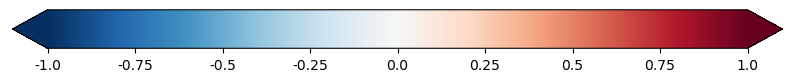

In [15]:
if __name__ == '__main__':
    plot_regression_colorbar()

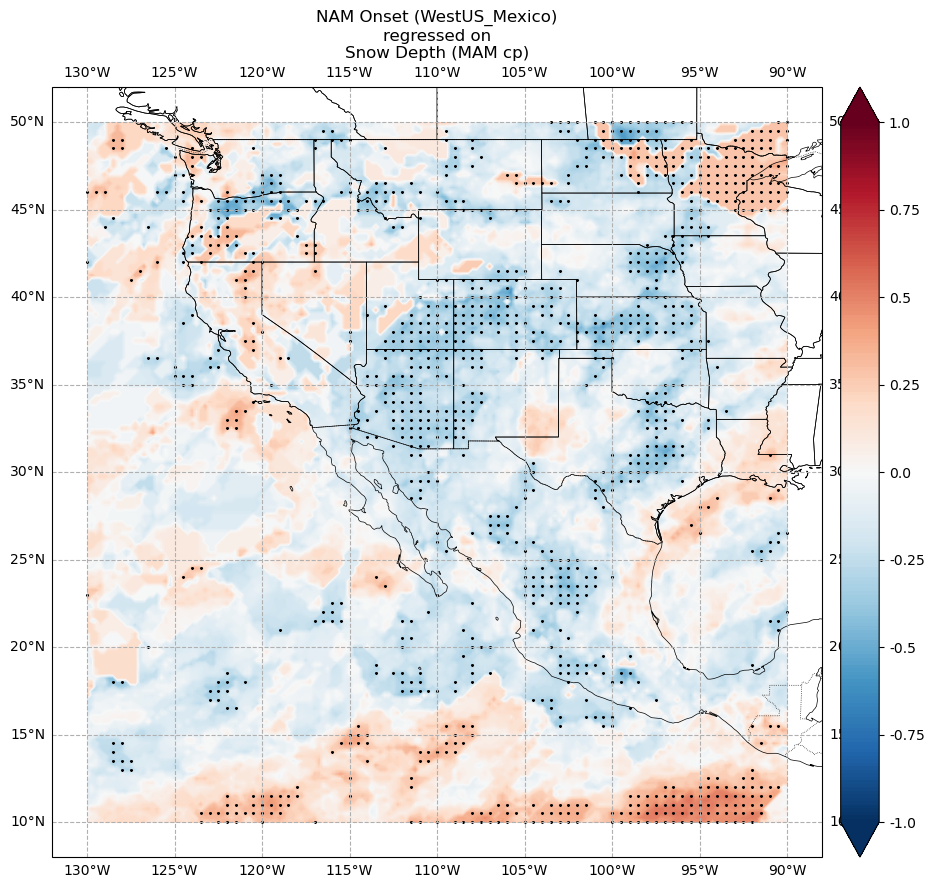

In [28]:
# test cell
if __name__ == '__main__':
    # required arguments
    var1 = 'sd'
    var1_months = [3, 4, 5]
    var1_region = "cp"
    var2 = 'onset'
    var2_months = [6, 7, 8, 9]
    var2_region = "WestUS_Mexico"
    # optional variable arguments
    var_kwargs = {
        "var1_level": 500,
        "var2_level": 500,
        "var1_elevation_mask": 1500,
        "var2_elevation_mask": 1500,
    }
    # other optional arguments
    main_kwargs = {
        "time_group": "year",
        "show_png": True,
        "save_png": False,
        "overwrite_flag": True,
        "plot_vectors": False,  # not implemented
        "plot_type": 'plot',
        "dpi": 300,
    }
    if __name__ == "__main__":
        kwargs = main_kwargs.copy()
        if var1 in pl_var_list:
            kwargs.update({"var1_level": var_kwargs["var1_level"]})
        if var2 in pl_var_list:
            kwargs.update({"var2_level": var_kwargs["var2_level"]})
        if var1 == 'sd':
            kwargs.update({'var1_elevation_mask': var_kwargs['var1_elevation_mask']})
        if var2 == 'sd':
            kwargs.update({'var2_elevation_mask': var_kwargs['var2_elevation_mask']})
        main_regression(var1, var1_region, var1_months, var2, var2_region, var2_months, **kwargs)

In [ ]:
# plot em all
if __name__ == '__main__':
    # required arguments
    var1s = [
        'sd',
        'swvl1',
        'sd',
        'sd', 
        'swvl1',
        'swvl1',
        'sshf',
        'slhf',
        'z_thick_1000-500',
        ['viwve', 'viwvn'],
        'onset',
        'length',
    ]
    var1_regions = [
        'cp',
        'cp',
        'cp',
        'cp',
        'cp',
        'cp',
        'cp',
        'cp',
        'cp',
        'WestUS_Mexico',
        'MeNmAz',
        'MeNmAz',
    ]
    var1_monthss = [
        [3, 4, 5],
        [3, 4, 5],
        [3, 4, 5],
        [3, 4, 5],
        [3, 4, 5],
        [3, 4, 5],
        [4, 5, 6],
        [4, 5, 6],
        [6],
        [6, 7],
        [1],
        [1],
    ]
    var2s = [
        'onset',
        'onset',
        'sshf',
        'slhf',
        'sshf',
        'slhf',
        'z_thick_1000-500',
        'z_thick_1000-500',
        ['viwve', 'viwvn'],
        'length',
        'precipitation',
        'precipitation',
    ]
    var2_regions = [
        'WestUS_Mexico',
        'WestUS_Mexico',
        'WestUS_Mexico',
        'WestUS_Mexico',
        'WestUS_Mexico',
        'WestUS_Mexico',
        'WestUS_Mexico',
        'WestUS_Mexico',
        'WestUS_Mexico',
        'MeNmAz',
        'WestUS_Mexico',
        'WestUS_Mexico',
    ]
    var2_monthss = [
        [1],
        [1],
        [4, 5, 6],
        [4, 5, 6],
        [4, 5, 6],
        [4, 5, 6],
        [6],
        [6],
        [6, 7],
        [1],
        [1],
        [1],
    ]

    assert(len(var1s) == len(var1_regions) == len(var1_monthss) == len(var2s) == len(var2_regions) == len(var2_monthss))
    for i in range(len(var1s)):
        print(i)
        # optional variable arguments
        var_kwargs = {
            "var1_level": 500,
            "var2_level": 500,
        }
        # other optional arguments
        main_kwargs = {
            "time_group": "year",
            "show_png": True,
            "save_png": True,
            "overwrite_flag": True,
            "plot_vectors": True,  # not implemented
            "elevation_mask": True,  # not implemented
            "plot_type": 'figure',
            "dpi": 300,
        }
        if __name__ == "__main__":
            kwargs = main_kwargs.copy()
            if var1s[i] in pl_var_list:
                kwargs.update({"var1_level": var_kwargs["var1_level"]})
            if var2s[i] in pl_var_list:
                kwargs.update({"var2_level": var_kwargs["var2_level"]})
            main_regression(var1s[i], var1_regions[i], var1_monthss[i], var2s[i], var2_regions[i], var2_monthss[i], **kwargs)